## BISMILLAH MODEL TABULAR FIX FIX FIXXXX

# Import Library

In [1]:
import pandas as pd
import numpy as np
import joblib
import os
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score)
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import (EarlyStopping, ModelCheckpoint, TensorBoard)

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.21.0


# LOAD DATASET

In [2]:
df = pd.read_csv("dataset_gabungan_clean.csv")
print("Ukuran Dataset:", df.shape)
df.head()

Ukuran Dataset: (114376, 24)


C:\Users\user\AppData\Local\Temp\ipykernel_17092\853450347.py:1: DtypeWarning: Columns (10,11,21) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("dataset_gabungan_clean.csv")


,Gender,Age_Month,Weight,Height,BMI,ZScore_WA,ZScore_HA,ZScore_WH,Nutrition_Risk,Double_Burden,...,Bumil_Pil_FE,Bumil_KEK,Bumil_RESTI,Air_Minum_Aman,Jamban_Layak,JamKes,Pengasuh_Parenting,Konvergensi,Indeks_Risiko_Stunting,Label
0,0.0,54.0,13.2,97.5,13.885602,0.0,-2.11,-0.95,1.666667,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.0,44.0,12.0,92.0,14.177694,0.0,-2.22,-0.88,1.673333,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.0,57.0,14.0,97.0,14.879371,0.0,-2.58,-0.48,1.653333,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.0,26.0,11.0,79.0,17.625381,0.0,-3.11,0.68,1.193333,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,59.0,14.6,98.0,15.201999,0.0,-2.49,-0.18,1.443333,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# CEK INFORMASI DATASET

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114376 entries, 0 to 114375
Data columns (total 24 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Gender                  114376 non-null  float64
 1   Age_Month               114376 non-null  float64
 2   Weight                  114376 non-null  float64
 3   Height                  114376 non-null  float64
 4   BMI                     114376 non-null  float64
 5   ZScore_WA               114376 non-null  float64
 6   ZScore_HA               114376 non-null  float64
 7   ZScore_WH               114376 non-null  float64
 8   Nutrition_Risk          114376 non-null  float64
 9   Double_Burden           114376 non-null  float64
 10  Provinsi                114376 non-null  object 
 11  Kecamatan               114376 non-null  object 
 12  Ibu_Hamil               114376 non-null  float64
 13  Bumil_Cek_4Kali         114376 non-null  float64
 14  Bumil_Pil_FE        

In [4]:
print(df.isnull().sum())

Gender                    0
Age_Month                 0
Weight                    0
Height                    0
BMI                       0
ZScore_WA                 0
ZScore_HA                 0
ZScore_WH                 0
Nutrition_Risk            0
Double_Burden             0
Provinsi                  0
Kecamatan                 0
Ibu_Hamil                 0
Bumil_Cek_4Kali           0
Bumil_Pil_FE              0
Bumil_KEK                 0
Bumil_RESTI               0
Air_Minum_Aman            0
Jamban_Layak              0
JamKes                    0
Pengasuh_Parenting        0
Konvergensi               0
Indeks_Risiko_Stunting    0
Label                     0
dtype: int64


# CEK DISTRIBUSI LABEL

In [5]:
print(df["Label"].value_counts())

Label
0.0    114376
Name: count, dtype: int64


# Membuat Label Risiko Stunting

In [6]:
def buat_label_risiko(row):
    risiko_score = 0

    # Indikator antropometri
    if row["ZScore_HA"] < -2:
        risiko_score += 2
    elif row["ZScore_HA"] < -1:
        risiko_score += 1

    if row["ZScore_WA"] < -2:
        risiko_score += 1

    if row["ZScore_WH"] < -2:
        risiko_score += 1

    # Indikator risiko nutrisi
    if str(row["Nutrition_Risk"]).lower() not in ["normal", "aman", "0", "nan"]:
        risiko_score += 1

    # Indikator wilayah
    if row["Indeks_Risiko_Stunting"] >= 0.7:
        risiko_score += 2
    elif row["Indeks_Risiko_Stunting"] >= 0.4:
        risiko_score += 1

    # Penentuan label akhir
    if risiko_score <= 1:
        return "Aman"
    elif risiko_score <= 3:
        return "Perlu Perhatian"
    else:
        return "Risiko Tinggi"


df["Label"] = df.apply(buat_label_risiko, axis=1)

print(df["Label"].value_counts())

Label
Perlu Perhatian    77793
Aman               35193
Risiko Tinggi       1390
Name: count, dtype: int64


# MEMISAHKAN FITUR DAN LABEL

In [7]:
leakage_cols = [
    "Nutrition_Risk",
    "Indeks_Risiko_Stunting",
    "Konvergensi"
]

X = df.drop(
    columns=["Label"] + leakage_cols
)

y = df["Label"]

print("Jumlah fitur:", X.shape[1])
print("Jumlah data:", X.shape[0])

Jumlah fitur: 20
Jumlah data: 114376


# Encoding Fitur Kategorikal

In [8]:
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()

print("Kolom kategorikal:")
print(categorical_cols)

Kolom kategorikal:
['Provinsi', 'Kecamatan']


In [9]:
from sklearn.preprocessing import LabelEncoder

X_encoded = X.copy()

feature_label_encoders = {}

for col in categorical_cols:
    encoder = LabelEncoder()
    X_encoded[col] = X_encoded[col].astype(str)
    X_encoded[col] = encoder.fit_transform(X_encoded[col])
    feature_label_encoders[col] = encoder

print("Shape setelah encoding:", X_encoded.shape)

Shape setelah encoding: (114376, 20)


# Encoding Label

In [10]:
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Kelas Label:")
print(label_encoder.classes_)

Kelas Label:
['Aman' 'Perlu Perhatian' 'Risiko Tinggi']


# Split Dataset

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (91500, 20)
X_test: (22876, 20)


# Scaling Fitur

In [12]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Membuat Folder Output

In [13]:
os.makedirs("output_model_tabular", exist_ok=True)

# Custom Callback

In [14]:
class TrainingProgressCallback(tf.keras.callbacks.Callback):

    def on_epoch_end(self, epoch, logs=None):

        print(
            f"Epoch {epoch+1} selesai | "
            f"Accuracy: {logs['accuracy']:.4f} | "
            f"Val Accuracy: {logs['val_accuracy']:.4f}"
        )

# Membangun Model Deep Learning

In [15]:
num_features = X_train_scaled.shape[1]
num_classes = len(label_encoder.classes_)

inputs = layers.Input(shape=(num_features,))

x = layers.Dense(128, activation="relu")(inputs)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)

x = layers.Dense(64, activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)

x = layers.Dense(32, activation="relu")(x)
x = layers.Dropout(0.2)(x)

outputs = layers.Dense(
    num_classes,
    activation="softmax"
)(x)

model = Model(inputs=inputs, outputs=outputs)

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         2,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,891 (54.26 KB)

 Trainable params: 13,507 (52.76 KB)

 Non-trainable params: 384 (1.50 KB)

# Callback Training

In [16]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "output_model_tabular/best_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max"
)

custom_callback = TrainingProgressCallback()

# Training Model

In [17]:
history = model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_test_scaled, y_test),
    epochs=100,
    batch_size=32,
    callbacks=[
        early_stop,
        checkpoint,
        custom_callback
    ],
    verbose=0
)

Epoch 1 selesai | Accuracy: 0.7828 | Val Accuracy: 0.8094
Epoch 2 selesai | Accuracy: 0.8203 | Val Accuracy: 0.8379
Epoch 3 selesai | Accuracy: 0.8315 | Val Accuracy: 0.8515
Epoch 4 selesai | Accuracy: 0.8367 | Val Accuracy: 0.8571
Epoch 5 selesai | Accuracy: 0.8395 | Val Accuracy: 0.8342
Epoch 6 selesai | Accuracy: 0.8446 | Val Accuracy: 0.8529
Epoch 7 selesai | Accuracy: 0.8453 | Val Accuracy: 0.8589
Epoch 8 selesai | Accuracy: 0.8468 | Val Accuracy: 0.8604
Epoch 9 selesai | Accuracy: 0.8504 | Val Accuracy: 0.8562
Epoch 10 selesai | Accuracy: 0.8487 | Val Accuracy: 0.8454
Epoch 11 selesai | Accuracy: 0.8518 | Val Accuracy: 0.8592
Epoch 12 selesai | Accuracy: 0.8522 | Val Accuracy: 0.8532
Epoch 13 selesai | Accuracy: 0.8532 | Val Accuracy: 0.8686
Epoch 14 selesai | Accuracy: 0.8527 | Val Accuracy: 0.8459
Epoch 15 selesai | Accuracy: 0.8550 | Val Accuracy: 0.8518
Epoch 16 selesai | Accuracy: 0.8548 | Val Accuracy: 0.8445
Epoch 17 selesai | Accuracy: 0.8548 | Val Accuracy: 0.8601
Epoch 

# Visualisasi Hasil Training

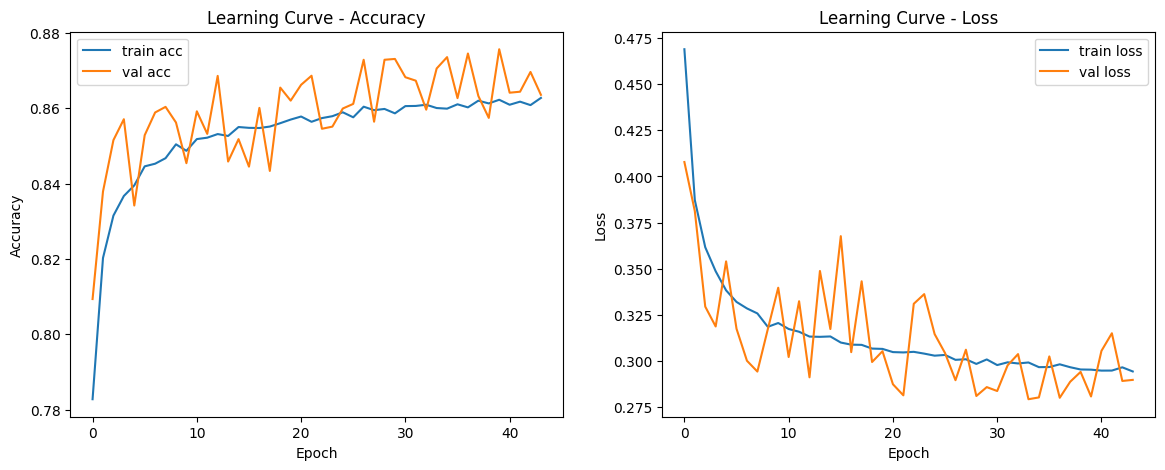

In [18]:
# Learning Curve
import matplotlib.pyplot as plt

os.makedirs("output_model_tabular/visualisasi", exist_ok=True)
plt.figure(figsize=(14,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.title('Learning Curve - Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.title('Learning Curve - Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.savefig(
    "output_model_tabular/visualisasi/learning_curve.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# Evaluasi Model

In [24]:
y_pred_prob = model.predict(X_test_scaled)

y_pred = np.argmax(y_pred_prob, axis=1)

715/715 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


In [31]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Akurasi Model: {accuracy:.4f}")
print(f"Akurasi Model (%): {accuracy * 100:.2f}%")

Akurasi Model: 0.8706
Akurasi Model (%): 87.06%


In [26]:
print(classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_.astype(str)
))

                 precision    recall  f1-score   support

           Aman       0.78      0.81      0.79      7039
Perlu Perhatian       0.91      0.90      0.90     15559
  Risiko Tinggi       0.96      0.97      0.97       278

       accuracy                           0.87     22876
      macro avg       0.88      0.89      0.89     22876
   weighted avg       0.87      0.87      0.87     22876



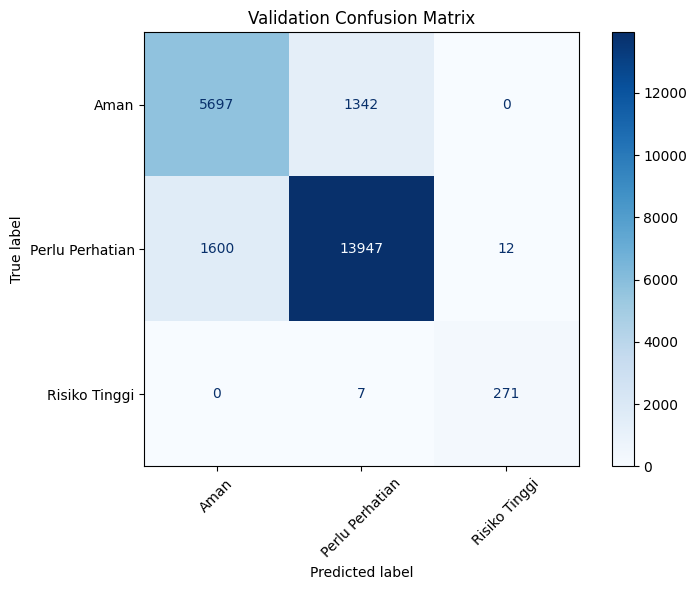

In [27]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_.astype(str)
)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap="Blues", values_format="d")

plt.title("Validation Confusion Matrix")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    "output_model_tabular/visualisasi/confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [28]:
print(confusion_matrix(y_test, y_pred))

[[ 5697  1342     0]
 [ 1600 13947    12]
 [    0     7   271]]


# Menyimpan Model 

In [29]:
model.save(
    "output_model_tabular/stunting_model_gabungan.keras"
)

joblib.dump(
    scaler,
    "output_model_tabular/scaler.pkl"
)

joblib.dump(
    label_encoder,
    "output_model_tabular/label_encoder.pkl"
)

joblib.dump(
    X_encoded.columns.tolist(),
    "output_model_tabular/feature_columns.pkl"
)

joblib.dump(
    feature_label_encoders,
    "output_model_tabular/feature_label_encoders.pkl"
)

print("Model berhasil disimpan.")

Model berhasil disimpan.


# Uji Coba Inference

In [30]:
sample_data = X.iloc[[0]].copy()

sample_encoded = pd.get_dummies(
    sample_data,
    columns=categorical_cols,
    drop_first=True
)

sample_encoded = sample_encoded.reindex(
    columns=X_encoded.columns,
    fill_value=0
)

sample_scaled = scaler.transform(sample_encoded)

prediction = model.predict(sample_scaled)

predicted_class = np.argmax(prediction, axis=1)[0]

predicted_label = label_encoder.inverse_transform(
    [predicted_class]
)[0]

print("Hasil Prediksi:", predicted_label)
print("Confidence Score:", np.max(prediction))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
Hasil Prediksi: Perlu Perhatian
Confidence Score: 0.99994004
